In [1]:
#export_file = 'project-2-at-2026-01-21-13-45-6a85ae9f.json'

export_file = "annotations.json"

import requests
import json

# Configuration
LABEL_STUDIO_URL = "http://192.168.4.35:8080"
API_KEY = "***REMOVED***"
PROJECT_ID = 2  # your project ID

# Export annotations
response = requests.get(
    f"{LABEL_STUDIO_URL}/api/projects/{PROJECT_ID}/export",
    headers={"Authorization": f"Token {API_KEY}"},
    params={"exportType": "JSON"}
)

annotations = response.json()

# Save to file
with open(export_file, "w") as f:
    json.dump(annotations, f, indent=2)

print(f"Downloaded {len(annotations)} bytes")

Downloaded 4159 bytes


In [2]:
import json
from pathlib import Path
import os

with open(export_file) as f:
    data = json.load(f)

print(f"Total annotations: {len(data)}")

sample = data[0]
image_path = sample['data']['image']
if '?d=' in image_path:
        image_path = image_path.split('?d=')[1]
        image_path = os.path.join("/import", image_path)
print(f"Example: {image_path} Exist:{os.path.exists(image_path)}")

Total annotations: 4159
Example: /import/arrows_ref/img/0.0_zeiger1_2019-06-04T044009.jpg Exist:True


In [3]:
import shutil

# Setup

resolution = 144

step = 0.5

#model_name = 'mobilenetv3_small_100' # 1.5M, 30s, baseline
#model_name = 'mobilenetv3_large_100' # 4M, 60s
#model_name = 'resnet34' # 21M, 176s, larger, but similar
##model_name = 'convnext_tiny' # 27M, 237s, epoch1= 4%, abort
#model_name = 'efficientnet_b0' # 4M, 100s, noth worth the tradeoff
model_name = 'efficientnet_lite0' 

dataset_dir = Path('dataset')

# Purge existing data
if dataset_dir.exists():
    shutil.rmtree(dataset_dir)

dataset_dir.mkdir(exist_ok=True)

for item in data:
    # Label extrahieren
    annotations = item.get('annotations', [])
    if not annotations:
        continue
    
    result = annotations[0]['result']
    if not result:
        continue
    
    label_float = result[0]['value']['number']
    
    label = f"{label_float:.1f}" # 0.1 steps
    #label = f"{round(label_float * 5) / 5:.1f}" # 0.2 steps
    #label = f"{round(label_float * 2) / 2:.1f}" # 0.5 steps
    #label = f"{label_float:.0f}" # 1 steps
    #label = str(int(label_float)) # 1 steps, round down

    if label == "10":
        label = "0"
    if label == "10.0":
        label = "0.0"
    
    # Klassen-Ordner
    class_dir = dataset_dir / label
    class_dir.mkdir(exist_ok=True)
    
    # Bild-Pfad extrahieren und anpassen
    img_path = item['data']['image']
    # Falls Pfad Format: /data/local-files/?d=images/file.jpg
    if '?d=' in img_path:
        img_path = img_path.split('?d=')[1]
        img_path = os.path.join("/import", img_path)
    
    src_file = Path(img_path)
    if src_file.exists():
        shutil.copy(src_file, class_dir / src_file.name)
        #print(f"✓ {label}/{src_file.name}")
    else:
        print(f"✗ Not found: {img_path}")

print(f"\nDataset structure created in: {dataset_dir}")


Dataset structure created in: dataset


In [4]:
import numpy as np
from collections import Counter

classes = [d.name for d in dataset_dir.iterdir() if d.is_dir()]
counts = np.array([len(list((dataset_dir/cls).glob('*'))) for cls in classes])

print(f"Classes          : {len(counts)}")
print(f"Total samples    : {counts.sum()}")
print(f"Min              : {counts.min()}")
print(f"Max              : {counts.max()}")
print(f"Mean             : {counts.mean():.1f}")
print(f"Median           : {np.median(counts):.1f}")
print(f"Std dev          : {counts.std():.1f}")
print(f"CV               : {counts.std()/counts.mean():.2f}")
print(f"Imbalance ratio : {counts.max()/counts.min():.1f}x")

print("")

# Show bottom/top 5 classes
sorted_idx = np.argsort(counts)
print(f"Smallest 5:")
for i in sorted_idx[:5]:
    print(f"  {classes[i]}: {int(counts[i])}")
    
print(f"Largest 5:")
for i in sorted_idx[-5:]:
    print(f"  {classes[i]}: {int(counts[i])}")

Classes          : 50
Total samples    : 4159
Min              : 7
Max              : 216
Mean             : 83.2
Median           : 72.0
Std dev          : 51.9
CV               : 0.62
Imbalance ratio : 30.9x

Smallest 5:
  8.6: 7
  5.4: 7
  8.2: 11
  7.8: 17
  0.6: 21
Largest 5:
  6.4: 167
  6.0: 168
  7.2: 169
  9.2: 178
  0.0: 216


# Pruning

import random
from pathlib import Path
import shutil

median_samples = int(np.median(counts))
print(f"Capping at median: {median_samples} samples per class")

removed_count = 0
for cls in classes:
    cls_path = dataset_dir / cls
    images = list(cls_path.glob('*'))
    
    if len(images) > median_samples:
        random.shuffle(images)
        to_remove = images[median_samples:]
        
        for img in to_remove:
            img.unlink()
            removed_count += 1
        
        print(f"{cls}: removed {len(to_remove)} (kept {median_samples})")

print(f"\nTotal removed: {removed_count}")
print(f"New dataset size: {counts.sum() - removed_count}")

In [15]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import torch
import random

class SubsampledImageFolder(ImageFolder):
    def __init__(self, root, transform=None, step=1.0):
        super().__init__(root, transform)
        self.step = step
        
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        
        if self.step != 0.1:
            # Original class name (z.B. "1.8")
            original = self.classes[label]
            if '.' in original:
                value = float(original)
                # Runden auf step (0.5 oder 1.0)
                rounded = round(value / self.step) * self.step
                mapped = f"{int(rounded)}.{int((rounded % 1) * 10)}" if self.step < 1 else f"{int(rounded)}.0"
                # Neuen label index finden
                label = self.classes.index(mapped)
        
        return img, label

# Separate transforms for train/val
train_transform = transforms.Compose([
    transforms.Resize((resolution, resolution)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((resolution, resolution)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset and create stratified split manually
dataset = ImageFolder('dataset')
indices_by_class = {}
for idx, (_, label) in enumerate(dataset):
    if label not in indices_by_class:
        indices_by_class[label] = []
    indices_by_class[label].append(idx)

train_idx = []
val_idx = []
random.seed(42)
for label, indices in indices_by_class.items():
    random.shuffle(indices)
    split_point = int(0.8 * len(indices))
    train_idx.extend(indices[:split_point])
    val_idx.extend(indices[split_point:])

# Create datasets with appropriate transforms
#train_dataset = ImageFolder('dataset', transform=train_transform)
train_dataset = SubsampledImageFolder('dataset', step=step)  # oder step=1.0
train_ds = Subset(train_dataset, train_idx)

#val_dataset = ImageFolder('dataset', transform=val_transform)
val_dataset = SubsampledImageFolder('dataset', step=step)  # oder step=1.0
val_ds = Subset(val_dataset, val_idx)

# DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, num_workers=2)

print(f"Classes: {dataset.classes}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")

Classes: ['0.0', '0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5', '6.0', '6.5', '7.0', '7.5', '8.0', '8.5', '9.0', '9.5']
Train samples: 3318
Val samples: 840


In [16]:
!pip install scikit-learn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Extract labels from train subset
train_labels = [dataset.targets[idx] for idx in train_idx]

# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class weights computed:")
print(f"  Min weight: {class_weights.min():.2f}")
print(f"  Max weight: {class_weights.max():.2f}")
print(f"  Weight ratio: {class_weights.max()/class_weights.min():.1f}x")

# Show weights for smallest classes
for i in np.argsort(counts)[:5]:
    print(f"  Class {dataset.classes[i]}: weight={class_weights[i]:.2f}")


Device: cpu
Class weights computed:
  Min weight: 0.65
  Max weight: 1.98
  Weight ratio: 3.0x
  Class 5.5: weight=1.51


IndexError: list index out of range

In [7]:
#!pip install timm
import timm

num_classes = len(dataset.classes)
model_filename = f'model_{model_name}_c{num_classes}_r{resolution}'

# Lightweight model für Intel iGPU
model = timm.create_model(model_name, 
                          pretrained=True, 
                          num_classes=len(dataset.classes),
                          #drop_rate=0.1
                         )
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#criterion = torch.nn.CrossEntropyLoss()
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

# Also save the loss/acc data over trainings
train_losses = []
val_accs = []
total_epochs = 0

print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Model: EfficientNet
Parameters: 3,435,058


Epoch 1/10 - Loss: 2.1482 - Val Acc: 64.71% - Time: 94.8s
Epoch 2/10 - Loss: 1.1590 - Val Acc: 73.15% - Time: 96.1s
Epoch 3/10 - Loss: 0.7959 - Val Acc: 75.97% - Time: 91.5s
Epoch 4/10 - Loss: 0.6693 - Val Acc: 73.62% - Time: 91.4s
Epoch 5/10 - Loss: 0.6042 - Val Acc: 84.29% - Time: 91.4s
Epoch 6/10 - Loss: 0.4538 - Val Acc: 79.13% - Time: 98.4s
Epoch 7/10 - Loss: 0.5314 - Val Acc: 83.00% - Time: 93.5s
Epoch 8/10 - Loss: 0.4185 - Val Acc: 82.42% - Time: 105.5s
Epoch 9/10 - Loss: 0.3590 - Val Acc: 82.42% - Time: 109.0s
Epoch 10/10 - Loss: 0.4497 - Val Acc: 83.94% - Time: 177.7s

Total training time: 1049.2s (17.5min)


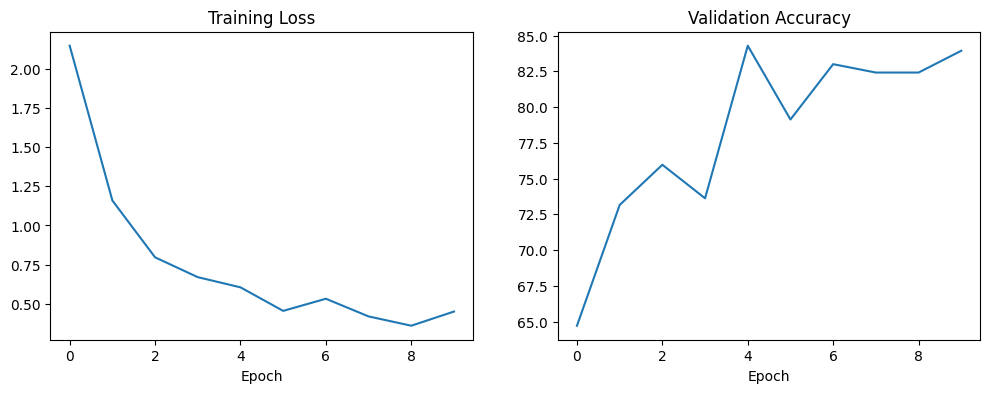

Best model from epoch 9 with 0.359 loss


In [8]:
import matplotlib.pyplot as plt
import time

epochs = 10

total_start = time.time()

best_val_loss = 1
best_epoch = 0
best_model_state = None

for epoch in range(epochs):
    epoch_start = time.time()

    # Training
    model.train()
    epoch_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    val_accs.append(val_acc)

    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        best_epoch = epoch
        best_model_state = model.state_dict().copy()


    epoch_time = time.time() - epoch_start
    
    print(f"Epoch {total_epochs+epoch+1}/{epochs+total_epochs} - Loss: {avg_loss:.4f} - Val Acc: {val_acc:.2f}% - Time: {epoch_time:.1f}s")

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s ({total_time/60:.1f}min)")
total_epochs += epochs

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax2.plot(val_accs)
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
plt.show()

model.load_state_dict(best_model_state)
print(f"Best model from epoch {best_epoch+1} with {best_val_loss:.3f} loss")

In [12]:
model.cpu()
model.eval()

dummy_input = torch.randn(1, 3, resolution, resolution)

# Legacy Export ohne dynamo
torch.onnx.export(
    model,
    dummy_input,
    f'{model_filename}.onnx',
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output']
)

print(f"✓ ONNX model saved: {model_filename}.onnx")


/tmp/ipykernel_13416/727429113.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


✓ ONNX model saved: model_efficientnet_lite0_c50_r144.onnx


In [13]:
import openvino as ov

# ONNX zu OpenVINO konvertieren
core = ov.Core()
model_onnx = core.read_model(f'{model_filename}.onnx')

# Kompilieren und serialisieren
ov.save_model(model_onnx, f'ov_model/{model_filename}.xml')

print(f"✓ OpenVINO model saved: ov_model/{model_filename}.xml")


✓ OpenVINO model saved: ov_model/model_efficientnet_lite0_c50_r144.xml


In [14]:
import openvino as ov
import cv2
import numpy as np

core = ov.Core()
print(f"Available devices: {core.available_devices}")

# Model laden + kompilieren
model_ov = core.read_model(f'ov_model/{model_filename}.xml')
compiled = core.compile_model(model_ov, 'GPU')

# Test Image
test_img_path = list(Path('dataset').rglob('*.jpg'))[0]
img = cv2.imread(str(test_img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (resolution, resolution))

# Preprocessing
img_normalized = img.astype(np.float32) / 255.0
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_normalized = (img_normalized - mean) / std
img_input = img_normalized.transpose(2, 0, 1)[np.newaxis, ...]

# Inference
result = compiled([img_input])[compiled.output(0)]

# Softmax für 0-1 Probabilities
result_softmax = np.exp(result[0]) / np.exp(result[0]).sum()
predicted_idx = result_softmax.argmax()
confidence = result_softmax[predicted_idx]

print(f"Test image: {test_img_path.name}")
print(f"Predicted class: {dataset.classes[predicted_idx]}")
print(f"Confidence: {confidence:.1%}")  # z.B. 98.5%


Available devices: ['CPU', 'GPU']
Test image: 0.6_zeiger4_2019-06-05T163009.jpg
Predicted class: 0.6
Confidence: 100.0%
